In [1]:
import torch

from torch.distributions import Normal

import matplotlib.pyplot as plt

torch.set_default_device('cuda:0')

In [2]:
prior = Normal(0.0, 5.0)

num_samples = 100000
z = prior.sample([num_samples])

n = 100
x = Normal(z, 1.0).sample([n]).permute(1,0)

In [3]:
class Encoder(torch.nn.Module):
    def __init__(self, num_hidden=128):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n, num_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(num_hidden, num_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(num_hidden, 2)
        )

    def forward(self, x):
        params = self.net(x)
        mean = params[:, 0]
        log_std = params[:, 1].clamp(-8.0, 8.0)
        return mean, log_std

In [4]:
class Lambda(torch.nn.Module):
    def __init__(self, init_value=1.0):
        super().__init__()
        self.raw = torch.nn.Parameter(torch.tensor(init_value))

    @property
    def value(self):
        return torch.nn.functional.softplus(self.raw) + 1e-8  # prevent exactly zero

In [5]:
encoder = Encoder(num_hidden=32)

In [6]:
lambda_module = Lambda(init_value=1.0)

In [7]:
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(lambda_module.parameters()), lr=1e-4)

In [8]:
num_epochs = 30000
batch_size = 512
delta = 0.32

for epoch in range(num_epochs):
    idx = torch.randint(0, num_samples, (batch_size,))
    x_batch = x[idx]
    z_batch = z[idx]

    mean, log_std = encoder(x_batch)
    std = torch.exp(log_std)

    logq = Normal(mean, std).log_prob(z_batch)
    lam = lambda_module.value

    scaled = -(1.0 / lam) * logq

    m = torch.max(scaled)
    log_exp_avg = m + torch.log(torch.mean(torch.exp(scaled - m)))

    loss = lam * (log_exp_avg + delta)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 25657.2852
Epoch 100, Loss: 196.2461
Epoch 200, Loss: 71.1220
Epoch 300, Loss: 26.2724
Epoch 400, Loss: 15.7950
Epoch 500, Loss: 9.5345
Epoch 600, Loss: 5.9473
Epoch 700, Loss: 4.3083
Epoch 800, Loss: 3.7161
Epoch 900, Loss: 3.4357
Epoch 1000, Loss: 3.0716
Epoch 1100, Loss: 2.8391
Epoch 1200, Loss: 2.4954
Epoch 1300, Loss: 2.2906
Epoch 1400, Loss: 2.1976
Epoch 1500, Loss: 2.1589
Epoch 1600, Loss: 2.0660
Epoch 1700, Loss: 2.0263
Epoch 1800, Loss: 1.9768
Epoch 1900, Loss: 1.8997
Epoch 2000, Loss: 1.7478
Epoch 2100, Loss: 1.6193
Epoch 2200, Loss: 1.5021
Epoch 2300, Loss: 1.3739
Epoch 2400, Loss: 1.2314
Epoch 2500, Loss: 1.1042
Epoch 2600, Loss: 1.0099
Epoch 2700, Loss: 0.9713
Epoch 2800, Loss: 1.0234
Epoch 2900, Loss: 1.0121
Epoch 3000, Loss: 0.9604
Epoch 3100, Loss: 0.9507
Epoch 3200, Loss: 0.9468
Epoch 3300, Loss: 0.9436
Epoch 3400, Loss: 0.9758
Epoch 3500, Loss: 1.1023
Epoch 3600, Loss: 0.9663
Epoch 3700, Loss: 0.9448
Epoch 3800, Loss: 0.9623
Epoch 3900, Loss: 0.9473
Epo

We evaluate on samples from the true generative model:

In [9]:
z_test = prior.sample([num_samples])

x_test = Normal(z_test, 1.0).sample([n]).permute(1,0)

In [10]:
m, ls = encoder(x_test)

In [11]:
confidence_levels = torch.linspace(0.05, 0.95, steps = 19)
quantiles = Normal(0, 1).icdf(1 - (1 - confidence_levels) / 2)

In [12]:
lower = (m.unsqueeze(-1) - quantiles * torch.exp(ls.unsqueeze(-1))).detach().cpu()
upper = (m.unsqueeze(-1) + quantiles * torch.exp(ls.unsqueeze(-1))).detach().cpu()

In [13]:
coverage_probs = ((z_test.cpu().unsqueeze(-1) >= lower) * (z_test.cpu().unsqueeze(-1) <= upper)).float().mean(0)

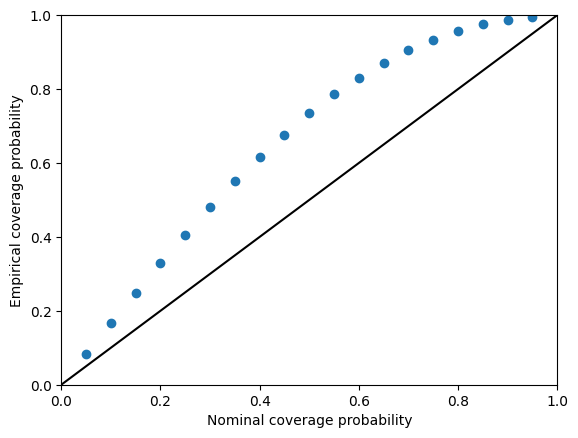

In [14]:
_ = plt.scatter(confidence_levels.cpu(), coverage_probs.cpu())
_ = plt.axline((0,0), slope = 1, color = 'black')
_ = plt.xlim(0, 1)
_ = plt.ylim(0, 1)
_ = plt.xlabel('Nominal coverage probability')
_ = plt.ylabel('Empirical coverage probability')

Now we evaluate on samples from an incorrect generative model — the conditional distribution of $x$ has 1.5 times the standard deviation of the true $p(x | z)$:

In [15]:
z_test = prior.sample([num_samples])

x_test = Normal(z_test, 1.5).sample([n]).permute(1,0)

In [16]:
m, ls = encoder(x_test)

In [17]:
confidence_levels = torch.linspace(0.05, 0.95, steps = 19)
quantiles = Normal(0, 1).icdf(1 - (1 - confidence_levels) / 2)

In [18]:
lower = (m.unsqueeze(-1) - quantiles * torch.exp(ls.unsqueeze(-1))).detach().cpu()
upper = (m.unsqueeze(-1) + quantiles * torch.exp(ls.unsqueeze(-1))).detach().cpu()

In [19]:
coverage_probs = ((z_test.cpu().unsqueeze(-1) >= lower) * (z_test.cpu().unsqueeze(-1) <= upper)).float().mean(0)

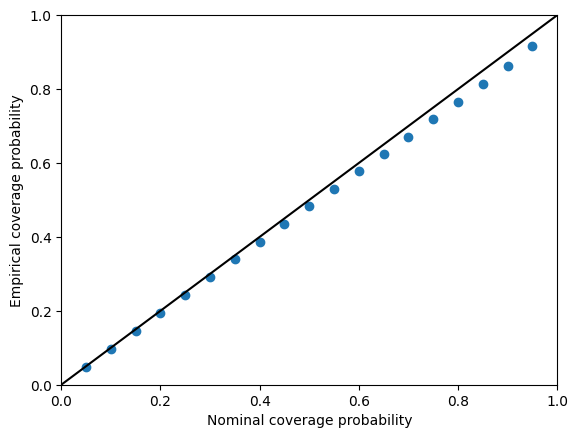

In [20]:
_ = plt.scatter(confidence_levels.cpu(), coverage_probs.cpu())
_ = plt.axline((0,0), slope = 1, color = 'black')
_ = plt.xlim(0, 1)
_ = plt.ylim(0, 1)
_ = plt.xlabel('Nominal coverage probability')
_ = plt.ylabel('Empirical coverage probability')